# Depth EDA Notebook

Minimal notebook for run summary and metric depth overlays.


In [1]:
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8')
np.set_printoptions(suppress=True, precision=4)


In [2]:
# Change this to inspect a different run
VIDEO_NAME = 'interaction_06'

SCRIPT_DIR = Path('.').resolve()
RUN_DIR = SCRIPT_DIR / 'output' / VIDEO_NAME
SUMMARY_JSON_PATH = RUN_DIR / 'run_summary.json'

with open(SUMMARY_JSON_PATH, 'r', encoding='utf-8') as f:
    summary_data = json.load(f)

FRAME_PATH = Path(summary_data['outputs']['frame_00'])
METRIC_DEPTH_PATH = Path(summary_data['outputs']['metric_depth']['npy'])
CAMERA_INTRINSICS_PATH = Path(summary_data['outputs']['camera_intrinsics']['json'])

relative_depth_info = summary_data['outputs'].get('relative_depth')
REL_DEPTH_PATH = None if relative_depth_info is None else Path(relative_depth_info['npy'])

frame_bgr = cv2.imread(str(FRAME_PATH), cv2.IMREAD_COLOR)
if frame_bgr is None:
    raise RuntimeError(f'Failed to read image: {FRAME_PATH}')
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

metric_depth = np.load(METRIC_DEPTH_PATH).astype(np.float32)
relative_depth = (
    np.load(REL_DEPTH_PATH).astype(np.float32)
    if REL_DEPTH_PATH is not None and REL_DEPTH_PATH.exists()
    else None
)

with open(CAMERA_INTRINSICS_PATH, 'r', encoding='utf-8') as f:
    camera_data = json.load(f)

fx = float(camera_data['intrinsics_pixels_3x3'][0][0])
fy = float(camera_data['intrinsics_pixels_3x3'][1][1])
cx = float(camera_data['intrinsics_pixels_3x3'][0][2])
cy = float(camera_data['intrinsics_pixels_3x3'][1][2])

print('Frame shape          :', frame_rgb.shape)
print('Metric depth shape   :', metric_depth.shape)
print('Relative depth shape :', None if relative_depth is None else relative_depth.shape)
print('Aligned to frame?    :', metric_depth.shape[:2] == frame_rgb.shape[:2])
print('Intrinsics fx, fy    :', round(fx, 4), round(fy, 4))
print('Principal point cx, cy:', round(cx, 4), round(cy, 4))
print('process_res_used     :', summary_data['inputs']['process_res_used'])
print('model_output_hw      :', summary_data['outputs']['metric_depth']['model_output_hw'])
print('saved_output_hw      :', summary_data['outputs']['metric_depth']['saved_output_hw'])
print('mask_percentile_range:', summary_data['outputs']['metric_depth']['mask_percentile_range'])


Frame shape          : (720, 1280, 3)
Metric depth shape   : (720, 1280)
Relative depth shape : None
Aligned to frame?    : True
Intrinsics fx, fy    : 1036.7646 1014.9888
Principal point cx, cy: 637.0 357.0
process_res_used     : 1280
model_output_hw      : [714, 1274]
saved_output_hw      : [720, 1280]
mask_percentile_range: {'p01': 3.380715432167053, 'p99': 5.157142210006714}


In [3]:
def robust_minmax(depth: np.ndarray, pmin: float = 1.0, pmax: float = 99.0) -> tuple[float, float]:
    valid = np.isfinite(depth) & (depth > 0)
    if valid.sum() == 0:
        return 0.0, 1.0
    vals = depth[valid]
    lo = float(np.percentile(vals, pmin))
    hi = float(np.percentile(vals, pmax))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(vals.min())
        hi = float(vals.max())
    if hi <= lo:
        hi = lo + 1e-6
    return lo, hi

def colorize_depth(depth: np.ndarray, cmap: str = 'turbo') -> np.ndarray:
    lo, hi = robust_minmax(depth)
    d = np.clip((depth - lo) / max(hi - lo, 1e-6), 0.0, 1.0)
    d = np.nan_to_num(d, nan=0.0, posinf=1.0, neginf=0.0)
    cm = plt.get_cmap(cmap)
    return (cm(d)[..., :3] * 255).astype(np.uint8)

def overlay_depth(frame_rgb: np.ndarray, depth: np.ndarray, alpha: float = 0.45, cmap: str = 'turbo') -> np.ndarray:
    depth_rgb = colorize_depth(depth, cmap=cmap)
    return np.clip((1 - alpha) * frame_rgb + alpha * depth_rgb, 0, 255).astype(np.uint8)


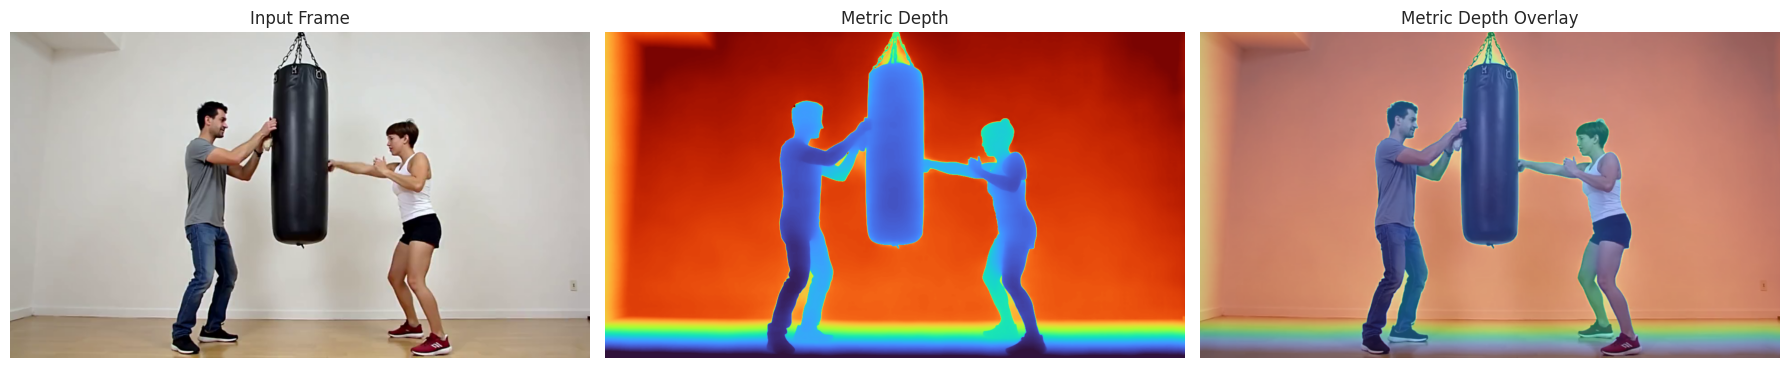

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(frame_rgb)
ax[0].set_title('Input Frame')

ax[1].imshow(colorize_depth(metric_depth, cmap='turbo'))
ax[1].set_title('Metric Depth')

ax[2].imshow(overlay_depth(frame_rgb, metric_depth, alpha=0.45, cmap='turbo'))
ax[2].set_title('Metric Depth Overlay')

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()
